In [1]:
# Instalación de skore.

%pip install -U skore[hub]

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/585.9 kB ? eta -:--:--
   ----------------------------------- ---- 524.3/585.9 kB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 585.9/585.9 kB 1.6 MB/s eta 0:00:00
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)

   ----------------------------------------  0/10 [uuid6]
   ----------------------------------------  0/10 [uuid6]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   -------- -------------------------------  2/10 [orjson]
   ------------ ----


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Let’s start by loading the “toxicity” dataset, a classification problem where we classify tweets as “toxic” or “not toxic”.

from skrub import TableReport, datasets

toxicity = datasets.fetch_toxicity()
X, y = toxicity.X, toxicity.y
TableReport(toxicity.toxicity)

Processing column   2 / 2


<TableReport: use .open() or .markdown() to display>

In [3]:
# We create a held-out test set to evaluate our final model once we are done experimenting.

from sklearn.model_selection import train_test_split

X_experiment, X_holdout, y_experiment, y_holdout = train_test_split(
    X, y, random_state=0
)

In [4]:
# Model no. 1: logistic regression with preprocessing.

from sklearn.linear_model import LogisticRegression
from skrub import tabular_pipeline

logistic_regression = tabular_pipeline(LogisticRegression())
logistic_regression

,steps,"[('tablevectorizer', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncod...ding='spline')
,specific_transformers,()
,drop_null_fraction,1.0


In [5]:
from skore import evaluate

logreg_cv_report = evaluate(
    logistic_regression, X_experiment, y_experiment, pos_label="Toxic", splitter=5
)
logreg_cv_report

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Metric,mean,std
Accuracy,0.828000,0.040387
Precision,0.827953,0.047129
Recall,0.833298,0.048512
ROC AUC,0.905555,0.036318
Log loss,0.386408,0.056205
Brier score,0.123921,0.022232
Fit time (s),5.965415,2.933636
Predict time (s),0.296566,0.101437
,steps,"[('tablevectorizer', ...), ('simpleimputer', ...), ...]"
,transform_input,None


In [6]:
# For example, we can examine the training data, which excludes the held-out data.

logreg_cv_report.data.summarize()

text   is_toxic
253  RACIST , EVIL INHUMAN POST ! WHERE ARE THE QUE...      Toxic
667  Gorgeous! Are you the artist? Do you have a we...  Not Toxic
85   Yeah I’m interested in the potential of this s...  Not Toxic
969  i would agree. we will see continuously more a...  Not Toxic
75    Smite jinx... int or pentakill?\n \n \n \n Both.  Not Toxic
..                                                 ...        ...
835  https://www.reddit.com/r/anime/comments/qkcuk6...  Not Toxic
192  MSNBC and CNN anchors are a bunch of freaks el...      Toxic
629  Biden the biggest douch bag in presidential hi...      Toxic
559                                   So super cute! 🖤  Not Toxic
684  His presidency isn't dead, his brain is. It's ...      Toxic

[750 rows x 2 columns]
Use .plot() to plot the data and .frame() to access the full data.

In [7]:
# Additionally we can run automatic checks on the model and get a summary of the findings.

logreg_cv_report.checks.summarize()

Output()

Checks summary: 0 issue(s), 3 tip(s), 8 passed, 5 not applicable, 0 skipped, 0 ignored.
Tips:
- [SKD006] Coefficient interpretation. Features are not on the same scale: coefficient magnitudes are not directly comparable as feature importance. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd006-unscaled-coefficients.
- [SKD009] Model performance vs. HistGradientBoosting baseline. Your model is on par with or better than a HistGradientBoosting baseline. Baseline performance on the test set, for reference: Accuracy=0.791, Brier score=0.155, Log loss=0.531, Precision=0.806, ROC AUC=0.877, Recall=0.773. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd009-worse-than-baseline.
- [SKD016] Estimator not tuned. Estimator(s) left at default settings; consider tuning: ['C'] for LogisticRegression. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd016-estimator-not-tuned.
Passed:
- [SKD001] Potential overfitting
- [SKD002] Potential underfitting
- [SKD003] Inconsistent performance across splits
- [SKD004] High class imbalance
- [SKD008] Highly correlated input features
- [SKD010] Model slower than baseline
- [SKD011] Golden feature
- [SKD012] Useless features
Not Applicable:
- [SKD005] Underrepresented classes. ML task is not multiclass classification. Got binary-classification. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd005-underrepresented-classes.
- [SKD007] MDI biased for high-cardinality features. Estimator is not a tree-based model: it does not have a `feature_importances_` attribute. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd007-mdi-cardinality-bias.
- [SKD013] Train-test overlap in time series. No datetime column found. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd013-train-test-time-overlap.
- [SKD014] Hyperparameters at search edge. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd014-hyperparams-at-search-edge.
- [SKD015] Hyperparameters worth tuning. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd015-hyperparameters-worth-tuning.
Mute a check with .checks.summarize(ignore=['<code>']).

In [ ]:
# But we can also quickly get an overview of the performance of our model, using summarize().
# favorability=True adds a column showing whether higher or lower metric values are better.

logreg_metrics = logreg_cv_report.metrics.summarize()
logreg_metrics.frame(favorability=True)

Output()

,logisticregression_mean,logisticregression_std,favorability
metric,,,
accuracy,0.828000,0.040387,(↗︎)
precision,0.827953,0.047129,(↗︎)
recall,0.833298,0.048512,(↗︎)
roc_auc,0.905555,0.036318,(↗︎)
log_loss,0.386408,0.056205,(↘︎)
brier_score,0.123921,0.022232,(↘︎)
fit_time,5.965415,2.933636,(↘︎)
predict_time,0.296566,0.101437,(↘︎)


In [9]:
# In addition to the summary of metrics, skore provides more advanced statistical information such as the precision-recall curve.

precision_recall = logreg_cv_report.metrics.precision_recall()
precision_recall.help()

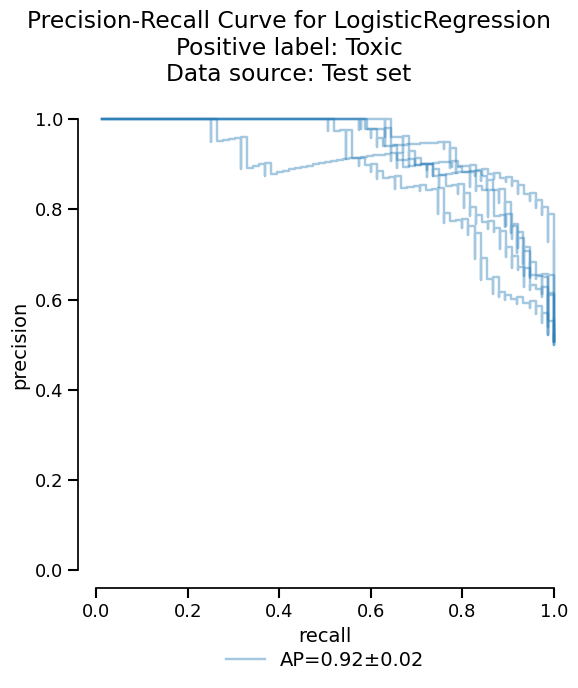

In [11]:
# We can visualize the critical information as a plot, with only a few lines of code:.

precision_recall.plot()

In [12]:
# Or we can access the raw information as a dataframe if additional analysis is needed.

precision_recall.frame()

,split,threshold,precision,recall
0,0,0.003018,0.506667,1.000000
1,0,0.028402,0.524138,1.000000
2,0,0.028555,0.520833,0.986842
3,0,0.095186,0.609756,0.986842
4,0,0.098096,0.606557,0.973684
...,...,...,...,...
469,4,0.992720,1.000000,0.066667
470,4,0.993688,1.000000,0.053333
471,4,0.996694,1.000000,0.040000
472,4,0.997928,1.000000,0.026667


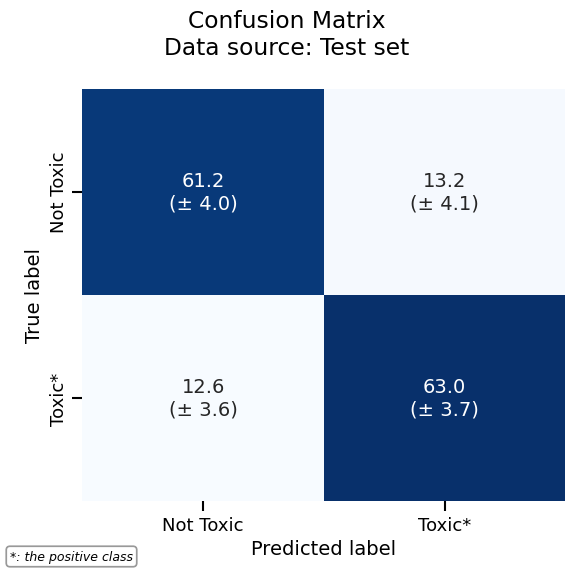

In [14]:
# As another example, we can plot the confusion matrix with the same consistent API.

confusion_matrix = logreg_cv_report.metrics.confusion_matrix()
confusion_matrix.plot()

In [15]:
# Skore also provides utilities to inspect models. Since our model is a linear model, we can study the importance that it gives to each feature.

coefficients = logreg_cv_report.inspection.coefficients()
coefficients.frame()

,feature,coefficient_mean,coefficient_std
0,Intercept,-0.229594,0.073703
1,text_00,0.525716,0.056630
2,text_01,0.632411,0.196744
3,text_02,-0.027981,2.314581
4,text_03,0.333833,1.086674
5,text_04,1.132879,1.275688
6,text_05,0.183052,0.889087
7,text_06,0.419226,0.330006
8,text_07,-0.027887,0.368701
9,text_08,-0.055355,0.710572
